In [1]:
#install langgraph, langchain, langchain-openai, tavily-python, graphviz, matplotlib
!pip install langgraph langchain langchain-openai tavily-python graphviz matplotlib


In [2]:
#next use getpass to load API keys
from getpass import getpass
import os

#API key from openAI and tavily
os.environ['OpenAIApiKey'] = getpass('Enter your OpenAI API key: ')
os.environ['TavilyApiKey'] = getpass('Enter your Tavily')

Enter your OpenAI API key: ··········
Enter your Tavily··········


In [3]:
from langchain_openai import ChatOpenAI
import os

# Retrieve the API key set in the previous cell and pass it explicitly
openai_api_key = os.environ.get('OpenAIApiKey')
llm = ChatOpenAI(model='gpt-3.5-turbo', temperature=0, openai_api_key=openai_api_key)

In [4]:
#import tool decotator
#create websearch tool with tavily
from tavily import TavilyClient
from langchain.tools import tool
tavilykey = os.environ.get('TavilyApiKey')
@tool
def websearch(query:str):
  """
    Search the internet for real-time information, news, or facts.

    Use this tool when the user asks about current events, specific details
    not in your training data, or when you need to verify factual information.

    Args:
        query: A specific, standalone search string (e.g., 'current price of Bitcoin').
    """
  query = query.strip('"')
  try:
    client = TavilyClient(api_key = tavilykey)
    response = client.search(query = query,
                      search_depth= "basic",
                      max_results = 3
    )
    return response
  except Exception as e:
    return str(e)
#create quant calculator
@tool
def calculator(math_expression:str):
  """
  returns the result of a mathematical expression

  use this tool when the user specically inputs math symbols +, -
  /, *, **. Use this tool when the user asks for a calculation to be done.

  args:
    math_expression: a string representing a mathematical expression
  """
  return eval(math_expression)

In [5]:
from langchain_core.utils.function_calling import convert_to_openai_function
tools = [websearch, calculator] #makes list
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools) # expects iterable of tool objects

In [6]:
#build nodes for llm and tool
from typing import Literal
from langgraph.graph import MessagesState, END
from langchain_core.messages import ToolMessage, SystemMessage, HumanMessage

# Define the system message once to avoid re-instantiation
ASSISTANT_SYSTEM_MESSAGE = SystemMessage(
    content="you are a helpful asssitant."
)

def llm_call (state: MessagesState):
  """ LLM decides whether to call a tool or not"""
  return {
      "messages": [llm_with_tools.invoke(
          [ASSISTANT_SYSTEM_MESSAGE]
          + state["messages"]
      )]
  }
def tool_node(state: dict):
  """ Performs tool call"""

  result = []
  for tool_call in state["messages"][-1].tool_calls:
    tool = tools_by_name[tool_call["name"]]
    observation = tool.invoke(tool_call["args"])
    result.append(ToolMessage(content = observation, tool_call_id=tool_call["id"]))
  return {
      "messages": result  }

In [7]:
#conditional edge where LLM decides to make it to a call or return itself as a message
from langgraph.graph import StateGraph, START, END, MessagesState

# Define the should_continue function (conditional edge)
def should_continue(state: MessagesState) -> Literal["environment", END]:
    messages = state["messages"]
    last_message = messages[-1]
    # If the LLM makes a tool call, then we route to the tool node.
    if last_message.tool_calls:
        return "Action"
    # Otherwise, we end the graph.
    return END
    #arrow at the top denotes a list of only possible type outputs

#build agent
agent_builder = StateGraph(MessagesState)

#Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("environment", tool_node)

#Add edges, to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        #Name returned by should continue is the name of the next node to visit
        "Action": "environment",
        END: END
    }
 )
agent_builder.add_edge("environment", "llm_call")

#compile the agent
agent = agent_builder.compile()

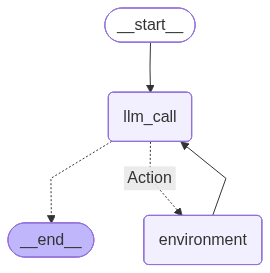

In [8]:
#cool, visualize agent
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [9]:
#basic message structure
def HumanMessaging():
  print("Enter your message: ")
  content = input("") # No prompt text
  content = content.strip('"')
  messages = [HumanMessage(content = content)]
  messages = agent.invoke({"messages": messages})
  for m in messages["messages"]:
    m.pretty_print()
HumanMessaging()

Enter your message: 
how much heavier is a moose than a deer
================================ Human Message =================================

how much heavier is a moose than a deer
================================== Ai Message ==================================
Tool Calls:
  websearch (call_uz7sTovzULrInSigeCXqFh4q)
 Call ID: call_uz7sTovzULrInSigeCXqFh4q
  Args:
    query: weight difference between moose and deer
================================= Tool Message =================================

{'query': 'weight difference between moose and deer', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://a-z-animals.com/animals/comparison/moose-vs-deer/', 'title': 'Moose vs. Deer: What Are the Differences? - A-Z Animals', 'content': 'Moose also weigh more than other deer. A moose can weigh between 600 and 1,500 pounds. A moose can weigh between 600 pounds and upwards of 1,500', 'score': 0.91175514, 'raw_content': None}, {'url': 'https://www.tiktok.com/@k